# Multi-DOF, multi-objective beamline optimization (blop) with raytracing (Shadow)
khchan@lbl.gov awojdyla@lbl.gov, Sep 2025

This script is based on blop 0.71

using `python 3.10.9` environment


In [2]:
from blop.utils import prepare_re_env

%run -i $prepare_re_env.__file__ --db-type=temp
# it would be great to have a proper bluesky database

C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
%matplotlib inline

import Shadow
import numpy as np
import matplotlib as mpl
from pathlib import Path
from matplotlib import pyplot as plt

In [4]:
# getting the beam size in for any beam shape
def beam_rms_size(x, y, intensity):
    """
    Compute the RMS (root mean square) beam size and centroid from ray data.

    This function calculates the second-moment beam size in both X and Y
    directions directly from a list of ray positions, using only rays
    that exist (I > 0).

    Parameters
    ----------
    x : 1D numpy.ndarray
        Array of X positions of rays (in meters, mm, etc.).
    y : 1D numpy.ndarray
        Array of Y positions of rays (same units as x).
    I : 1D numpy.ndarray
        Array of ray existence flags or intensities.
        Rays with I <= 0 are ignored.

    Returns
    -------
    total_rays : int
        Number of rays considered (I > 0).
    sigma_x : float
        RMS beam size in X direction.
    sigma_y : float
        RMS beam size in Y direction.
    x_centroid : float
        Centroid position in X.
    y_centroid : float
        Centroid position in Y.

    Notes
    -----
    - The RMS size is defined as:
        sigma_x = sqrt(mean((x - x_centroid)^2))
        sigma_y = sqrt(mean((y - y_centroid)^2))
      over all valid rays.
    - For a Gaussian beam, the FWHM can be obtained as:
        FWHM = 2.35482 * sigma
    - This method is robust and fast, and does not assume a Gaussian profile.

    Examples
    --------
    >>> total, sigma_x, sigma_y, cx, cy = beam_rms_size_from_rays(x, y, I)
    >>> fwhm_x = 2.35482 * sigma_x
    >>> fwhm_y = 2.35482 * sigma_y
    """
    #mask = np.all((np.abs(x) > 1e-8, np.abs(x) < 2e-3, np.abs(y) > 1e-8, np.abs(y) < 2e-3), 0)
    x_valid = x
    y_valid = y
    I_valid = intensity

    # intensity
    total_intensity = np.sum(intensity)
    # total_rays = len(x_valid)


    # Centroid positions
    # x_centroid = np.mean(x_valid)
    # y_centroid = np.mean(y_valid)

    # RMS sizes
    # sigma_x = np.sqrt(np.mean((x_valid - x_centroid) ** 2))
    # sigma_y = np.sqrt(np.mean((y_valid - y_centroid) ** 2))

    # Weighted centroids
    x_centroid = np.sum(I_valid * x_valid) / total_intensity
    y_centroid = np.sum(I_valid * y_valid) / total_intensity

    # Weighted RMS sizes
    sigma_x = np.sqrt(np.sum(I_valid * (x_valid - x_centroid) ** 2) / total_intensity)
    sigma_y = np.sqrt(np.sum(I_valid * (y_valid - y_centroid) ** 2) / total_intensity)
    # to avoid division by 0
    if I_valid.shape[0] < 50 or sigma_x<1e-10 or sigma_y<1e-10:
        return 1e-5, 100, 100, 100, 100

    return total_intensity, sigma_x, sigma_y, x_centroid, y_centroid

Define the beamline5.3.1 by shadow

In [5]:
"""
# mirror pitch (DOF1)
oe1.X_ROT = 1e-09
# mirror bend (DOF2)
oe1.R_MAJ = 2400.0

# Mono angle – same variable  (DOF3)
oe2.T_INCIDENCE = 75.6898061088
oe2.T_REFLECTION = 75.6898061088
oe3.T_INCIDENCE = 75.6898061088
oe3.T_REFLECTION = 75.6898061088

# slit position (DOF4)
oe4.CX_SLIT = numpy.array([1e-09, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
oe4.CZ_SLIT = numpy.array([1e-09, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

# write (1) or not (0) SHADOW files start.xx end.xx star.xx

iwrite = 0
"""

def beamline_531(X_ROT = 0, R_MAJ = 2400, MONO_ANGLE = 75.6898061088, SLIT_CX = 1e-9, SLIT_CZ = 1e-9, SLIT_RX = 1e-3, SLIT_RZ = 5e-4):
    # Define the object in beamline
    beam = Shadow.Beam()
    oe0 = Shadow.Source()
    oe1 = Shadow.OE()
    oe2 = Shadow.OE()
    oe3 = Shadow.OE()
    oe4 = Shadow.OE()
    oe5 = Shadow.OE()
    oe6 = Shadow.OE()
    
    
    oe0.FDISTR = 3
    oe0.F_PHOT = 0
    oe0.F_POLAR = 0
    oe0.HDIV1 = 0.0
    oe0.HDIV2 = 0.0
    oe0.IDO_VX = 0
    oe0.IDO_VZ = 0
    oe0.IDO_X_S = 0
    oe0.IDO_Y_S = 0
    oe0.IDO_Z_S = 0
    oe0.ISTAR1 = 0
    oe0.NPOINT = 50000
    oe0.PH1 = 8000.0
    oe0.SIGDIZ = 1e-05
    oe0.SIGMAX = 0.0003
    oe0.SIGMAZ = 0.0001
    oe0.VDIV1 = 0.0
    oe0.VDIV2 = 0.0
    
    
    
    oe1.ALPHA = 180.0
    oe1.DUMMY = 100.0
    oe1.FMIRR = 3
    oe1.FWRITE = 1
    oe1.F_EXT = 1
    oe1.F_MOVE = 1
    oe1.R_MAJ = R_MAJ
    oe1.R_MIN = 0.06
    oe1.T_IMAGE = 0.0
    oe1.T_INCIDENCE = 89.7135211024
    oe1.T_REFLECTION = 89.7135211024
    oe1.T_SOURCE = 12.0
    oe1.X_ROT = X_ROT
    oe1.Y_ROT = 0
    
    
    oe2.DUMMY = 100.0
    oe2.FILE_REFL = b'./bragg.dat'
    oe2.FWRITE = 1
    oe2.F_CENTRAL = 1
    oe2.F_CRYSTAL = 1
    oe2.PHOT_CENT = 8000.0
    oe2.R_LAMBDA = 5000.0
    oe2.T_IMAGE = 0.0
    oe2.T_INCIDENCE = MONO_ANGLE # 75.6898061088
    oe2.T_REFLECTION = MONO_ANGLE #75.6898061088
    
    
    
    oe3.ALPHA = 180.0
    oe3.DUMMY = 100.0
    oe3.FILE_REFL = b'./bragg.dat'
    oe3.FWRITE = 1
    oe3.F_CENTRAL = 1
    oe3.F_CRYSTAL = 1
    oe3.PHOT_CENT = 8000.0
    oe3.R_LAMBDA = 5000.0
    oe3.T_IMAGE = 0.0
    oe3.T_INCIDENCE = MONO_ANGLE # 75.6898061088
    oe3.T_REFLECTION = MONO_ANGLE # 75.6898061088
    oe3.T_SOURCE = 0.2

    
    oe4.CX_SLIT = np.array([SLIT_CX, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    oe4.CZ_SLIT = np.array([SLIT_CZ, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    oe4.DUMMY = 100.0
    oe4.FWRITE = 3
    oe4.F_REFRAC = 2
    oe4.F_SCREEN = 1
    oe4.I_SLIT = np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])
    oe4.N_SCREEN = 1
    oe4.RX_SLIT = np.array([SLIT_RX, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    oe4.RZ_SLIT = np.array([SLIT_RZ, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    oe4.T_IMAGE = 0.0
    oe4.T_INCIDENCE = 0.0
    oe4.T_REFLECTION = 180.0
    oe4.T_SOURCE = 0.8
    
    
    
    oe5.DUMMY = 100.0
    oe5.FWRITE = 3
    oe5.F_REFRAC = 2
    oe5.F_SCREEN = 1
    oe5.N_SCREEN = 1
    oe5.T_IMAGE = 0.0
    oe5.T_INCIDENCE = 0.0
    oe5.T_REFLECTION = 180.0
    oe5.T_SOURCE = 1.0

    beam.genSource(oe0)
    beam.traceOE(oe1,1)
    beam.traceOE(oe2,2)
    beam.traceOE(oe3,3)
    beam.traceOE(oe4,4)
    beam.traceOE(oe5,5)

    X = beam.getshcol(1)
    Y = beam.getshcol(3)
    # normalize the intensity by the number of rays
    valid = beam.getshcol(10) > 0
    intensity = (beam.getshcol(7)+beam.getshcol(16))**2 + (beam.getshcol(8)+beam.getshcol(17))**2 + (beam.getshcol(9)++beam.getshcol(18))**2
    mask = valid>0
    print(np.sum(mask))
    print(np.sum(intensity[mask]))
    X = X[mask]
    Y = Y[mask]
    intensity = intensity[mask]
    return X,Y,intensity

1230
347.5616899970936


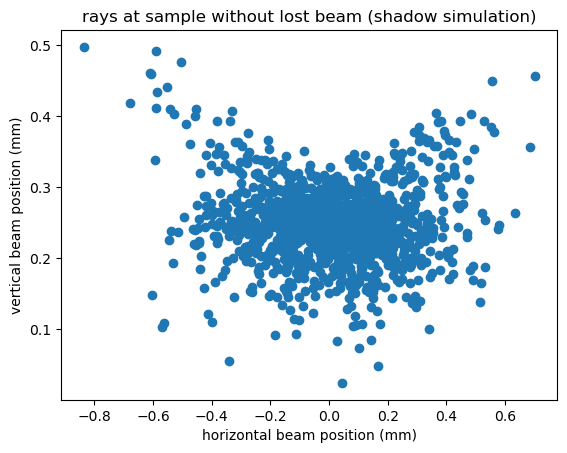

In [6]:
(X,Y,intensity) = beamline_531(0.001)
# intensity
plt.scatter(1e3*X,1e3*Y)
plt.title('rays at sample without lost beam (shadow simulation)')
plt.xlabel('horizontal beam position (mm)')
plt.ylabel('vertical beam position (mm)')
plt.show()

In [7]:
(total_intensity, sigma_x, sigma_y, x_centroid, y_centroid) = beam_rms_size(X, Y, intensity)

In [8]:
total_intensity, sigma_x, sigma_y, x_centroid, y_centroid

(347.5616899970936,
 0.0002232341440671662,
 3.8280372119852184e-05,
 8.846576041788259e-06,
 0.00021063436684014733)

In [9]:
from blop import Objective
# power density
objectives = [Objective(name="power_density", description="power_density", target="max"),
              #Objective(name="beamsize", description="beamsize", target="min"), 
             #Objective(name="beam_intensity", description="beam_intensity", target="max"),
             #Objective(name="slit_size", description="slit_size", target="min"),
             ]

In [10]:
# from https://nsls-ii.github.io/blop/tutorials/introduction.html
# def digestion(df):
#     for index, entry in df.iterrows():
#         df.loc[index, "himmelblau"] = functions.himmelblau(entry.x1, entry.x2)

#     return df

#new: 
# unit log / normalize
# x_rot = 0.00045  r_maj = 2271.625488mono_angle = 75.766228
def digestion(df):
    for index, entry in df.iterrows():
        # remove
        X, Y, I = beamline_531(entry.x_rot, entry.r_maj, entry.mono_angle)#, entry.slit_cx, entry.slit_cz)#, SLIT_RX = entry.slit_rx, SLIT_RZ = entry.slit_rz)
        (total_intensity, sigma_x, sigma_y, x_centroid, y_centroid) = beam_rms_size(X, Y, I) 
        # power density hist1, xedges, yedges = np.histogram2d(X*1e3, Y*1e3, bins=1, range=[[x_centroid-0.05, x_centroid+0.05], [y_centroid-0.05, y_centroid+0.05]])
        df.loc[index, "power_density"] = total_intensity/(sigma_x**2 + sigma_y**2)
        df.loc[index, "beamsize"] = np.sqrt(sigma_x**2 + sigma_y**2)
        df.loc[index, "beam_intensity"] = total_intensity
        #df.loc[index, "slit_size"] = np.sqrt(entry.slit_rx**2 + entry.slit_rz**2)
        print( total_intensity/np.sqrt(sigma_x**2 + sigma_y**2))

    return df

In [11]:
from blop import DOF
"""
dofs = [
    DOF(name="x_rot", search_domain=(-0.05, 0.05)),
    DOF(name="r_maj", search_domain=(2000, 2800)),
    DOF(name="slit_cx", search_domain=(-0.05, 0.05)),
    DOF(name="slit_cz", search_domain=(-0.05, 0.05)),
    DOF(name="slit_rx", search_domain=(0.001, 0.005)),
    DOF(name="slit_rz", search_domain=(0.001, 0.005)),
]
"""
# unit
dofs = [
    DOF(name="x_rot", search_domain=(-0.001, 0.001)),
    DOF(name="r_maj", search_domain=(2000, 4000)),
    DOF(name="mono_angle", search_domain=(74, 78)),
    #DOF(name="slit_cx", search_domain=(-0.005, 0.005)),
    #DOF(name="slit_cz", search_domain=(-0.005, 0.005)),
    #DOF(name="slit_rx", search_domain=(0.0001, 0.01)),
    #DOF(name="slit_rz", search_domain=(0.0001, 0.005)),
]

In [12]:
from blop import Agent

agent = Agent(
    dofs=dofs,
    objectives=objectives,
    digestion=digestion,
    db=db,
    
)

2025-09-26 13:36:02.144 INFO: Executing plan <generator object Agent.learn at 0x0000019E80ECA110>
2025-09-26 13:36:02.149 INFO: Change state on <bluesky.run_engine.RunEngine object at 0x0000019E800FC7C0> from 'idle' -> 'running'




Transient Scan ID: 1     Time: 2025-09-26 13:36:11
Persistent Unique Scan ID: '18d053a6-07ee-49fc-a4d1-81bafdd348c8'
New stream: 'primary'
+-----------+------------+------------+------------+------------+
|   seq_num |       time |      x_rot |      r_maj | mono_angle |
+-----------+------------+------------+------------+------------+
|         1 | 13:36:11.1 |     -0.000 |   2645.810 |     76.381 |
|         2 | 13:36:11.1 |     -0.000 |   2885.199 |     76.637 |
|         3 | 13:36:11.1 |     -0.000 |   3044.170 |     75.908 |
|         4 | 13:36:11.1 |     -0.000 |   2994.348 |     75.964 |
|         5 | 13:36:11.2 |     -0.001 |   3152.747 |     76.017 |
|         6 | 13:36:11.2 |     -0.001 |   2823.626 |     76.104 |
|         7 | 13:36:11.2 |     -0.001 |   2535.269 |     75.552 |
|         8 | 13:36:11.2 |     -0.001 |   2807.751 |     75.309 |
|         9 | 13:36:11.2 |     -0.001 |   3008.139 |     74.999 |
|        10 | 13:36:11.3 |     -0.001 |   2968.112 |     74.881 |
|

C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:312.)
  D[self.diag_matrix_indices] = self.lengthscales.ravel() ** -1
2025-09-26 13:38:00.346 INFO: Change state on <bluesky.run_engine.RunEngine object at 0x0000019E800FC7C0> from 'running' -> 'idle'
2025-09-26 13:38:00.349 INFO: Cleaned up from plan <generator object Agent.learn at 0x0000019E80ECA110>
C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytor

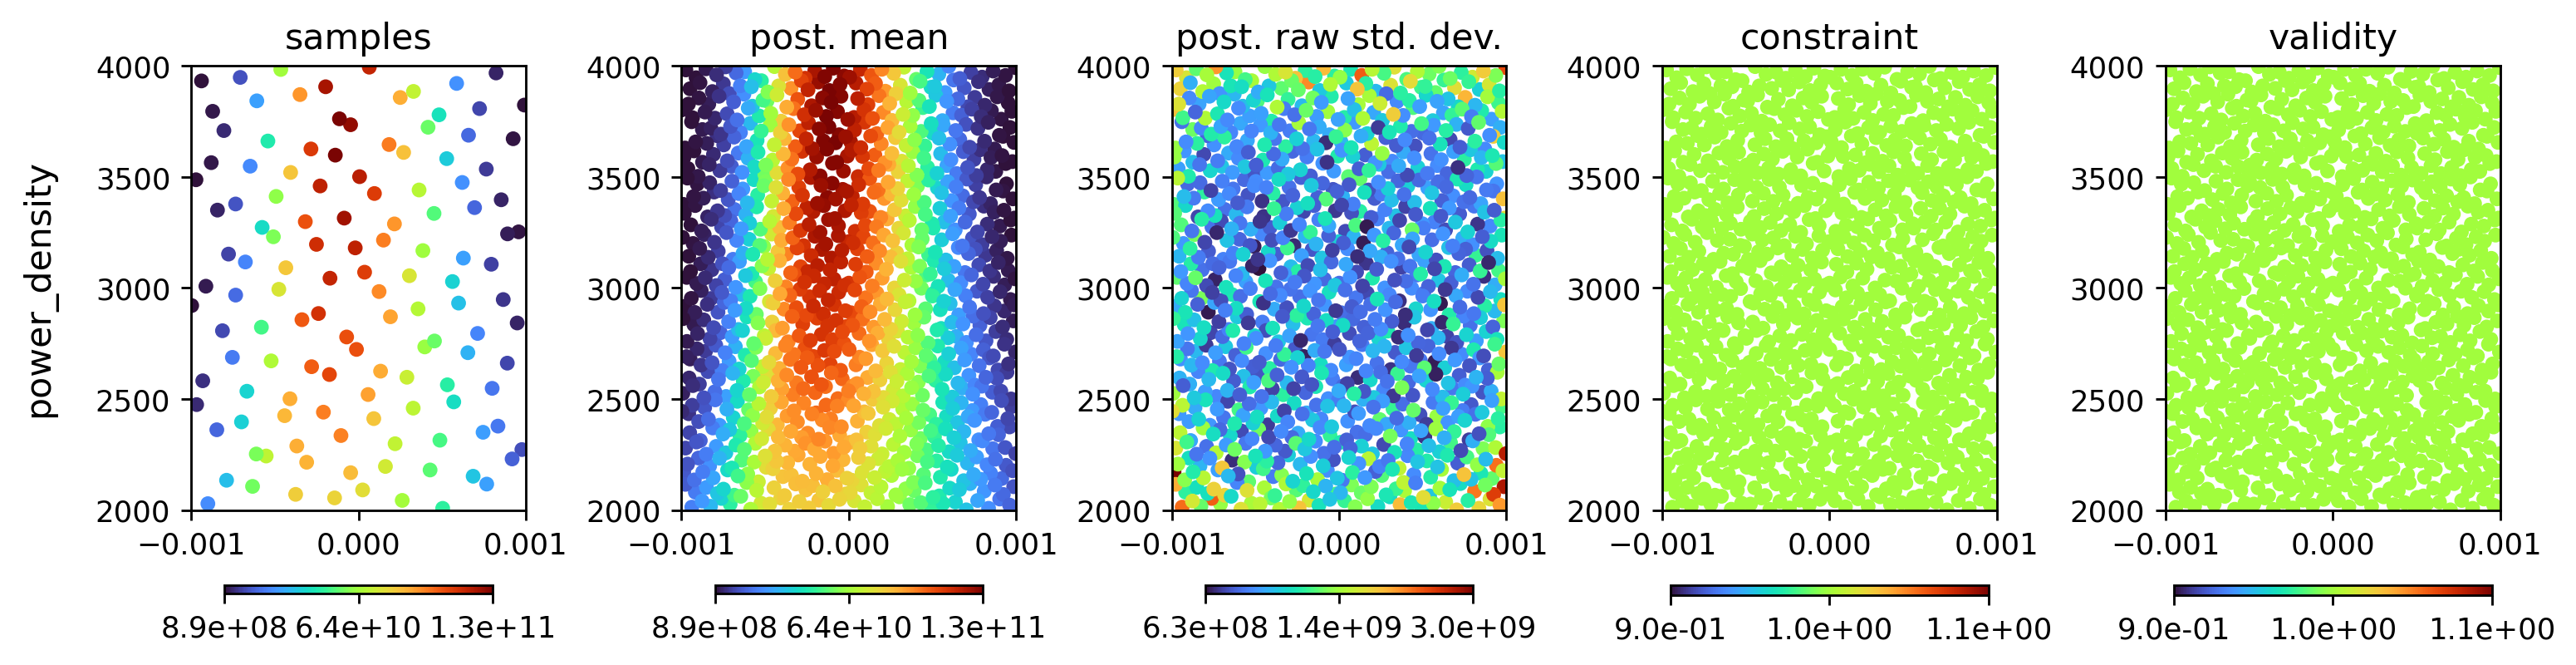

In [13]:
RE(agent.learn("quasi-random", n=128))
agent.plot_objectives()

In [14]:
agent.all_acqfs

,identifier,type,multitask_only,description
name,,,,
expected_improvement,ei,analytic,False,"The expected value of max(f(x) - \nu, 0), wher..."
expected_mean,em,analytic,False,The expected value at each input.
noisy_expected_hypervolume_improvement,nehvi,analytic,True,It's like a big box. How big is the box?
probability_of_improvement,pi,analytic,False,The probability that this input improves on th...
upper_confidence_bound,ucb,analytic,False,"The expected value, plus some multiple of the ..."
lower_bound_max_value_entropy,lbmve,monte_carlo,False,"Max entropy search, basically"
monte_carlo_expected_improvement,qei,monte_carlo,False,"The expected value of max(f(x) - \nu, 0), wher..."
monte_carlo_expected_mean,qem,monte_carlo,False,The expected value at each input.
monte_carlo_noisy_expected_hypervolume_improvement,qnehvi,monte_carlo,True,It's like a big box. How big is the box?


C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:312.)
  D[self.diag_matrix_indices] = self.lengthscales.ravel() ** -1


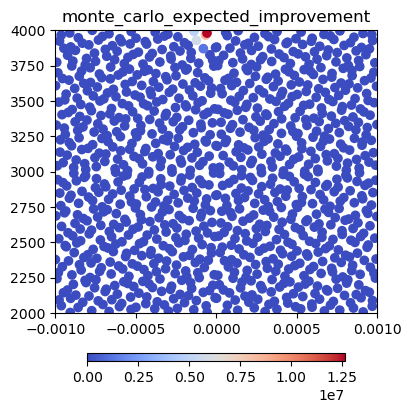

In [26]:
agent.plot_acquisition(acqf="qei")

In [15]:
RE(agent.learn("qei", n=5, iterations=10))

2025-09-26 13:38:03.499 INFO: Executing plan <generator object Agent.learn at 0x0000019E858BA180>
2025-09-26 13:38:03.505 INFO: Change state on <bluesky.run_engine.RunEngine object at 0x0000019E800FC7C0> from 'idle' -> 'running'




Transient Scan ID: 2     Time: 2025-09-26 13:38:16
Persistent Unique Scan ID: '0422c181-5dc5-4b3f-9ed8-d87fd9168777'
New stream: 'primary'
+-----------+------------+------------+------------+------------+
|   seq_num |       time |      x_rot |      r_maj | mono_angle |
+-----------+------------+------------+------------+------------+
|         1 | 13:38:16.3 |     -0.000 |   4000.000 |     74.178 |
|         2 | 13:38:16.3 |     -0.000 |   4000.000 |     75.574 |
|         3 | 13:38:16.3 |     -0.000 |   3871.410 |     75.759 |
|         4 | 13:38:16.4 |     -0.000 |   3954.779 |     76.408 |
|         5 | 13:38:16.4 |     -0.000 |   3546.196 |     77.097 |
+-----------+------------+------------+------------+------------+
generator list_scan ['0422c181'] (scan num: 2)



14068
8815.616989642494
33210992.95326674
13815
8723.29821428093
32734244.591325983
13104
8487.102033832405
31385424.418640167
12424
8303.821503709283
31156032.053590562
15508
8416.105903792264
31973076.69354955


C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc



Transient Scan ID: 3     Time: 2025-09-26 13:38:22
Persistent Unique Scan ID: '33ee7f68-4f70-4aed-bcd9-c16b8d13c11f'
New stream: 'primary'
+-----------+------------+------------+------------+------------+
|   seq_num |       time |      x_rot |      r_maj | mono_angle |
+-----------+------------+------------+------------+------------+
|         1 | 13:38:22.6 |     -0.001 |   3246.409 |     75.612 |
|         2 | 13:38:22.6 |      0.000 |   3306.238 |     74.622 |
|         3 | 13:38:22.6 |     -0.000 |   3073.370 |     75.497 |
|         4 | 13:38:22.7 |     -0.000 |   2590.098 |     75.881 |
|         5 | 13:38:22.7 |     -0.001 |   3088.405 |     77.703 |
+-----------+------------+------------+------------+------------+
generator list_scan ['33ee7f68'] (scan num: 3)



8459
4465.584688234231
15759464.582480587
16497
2813.611137161422
11542273.342335163
16761
7664.979791007444
29711992.71853882
17361
6787.6116137438985
26152349.185218688
626
208.515183861265
639606.8934613885


C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc

...



Transient Scan ID: 10     Time: 2025-09-26 13:39:07
Persistent Unique Scan ID: '3be3df64-5fca-4885-8c42-63ee3574f35b'
New stream: 'primary'
+-----------+------------+------------+------------+------------+
|   seq_num |       time |      x_rot |      r_maj | mono_angle |
+-----------+------------+------------+------------+------------+
|         1 | 13:39:07.0 |     -0.000 |   2850.071 |     74.177 |
|         2 | 13:39:07.1 |     -0.001 |   3738.378 |     75.203 |
|         3 | 13:39:07.1 |      0.000 |   3778.451 |     74.436 |
|         4 | 13:39:07.1 |      0.000 |   2703.148 |     74.054 |
|         5 | 13:39:07.2 |      0.001 |   3581.266 |     77.268 |
+-----------+------------+------------+------------+------------+
generator list_scan ['3be3df64'] (scan num: 10)



17748
7221.107260438499
28237816.528033175
7580
4071.9568094366714
14313399.0798872
16265
7086.661978843644
27469420.22953064
18353
4575.098469325269
18211990.686655276
15645
2188.417905032402
9041890.45748018


C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc



Transient Scan ID: 11     Time: 2025-09-26 13:39:13
Persistent Unique Scan ID: 'f6429785-146c-4613-8ca5-65b4d6e9574a'
New stream: 'primary'
+-----------+------------+------------+------------+------------+
|   seq_num |       time |      x_rot |      r_maj | mono_angle |
+-----------+------------+------------+------------+------------+
|         1 | 13:39:13.3 |      0.001 |   3592.028 |     74.808 |
|         2 | 13:39:13.4 |     -0.000 |   2830.204 |     74.299 |
|         3 | 13:39:13.4 |     -0.001 |   2463.934 |     74.421 |
|         4 | 13:39:13.4 |      0.000 |   2845.902 |     75.930 |
|         5 | 13:39:13.5 |      0.001 |   2282.549 |     77.264 |
+-----------+------------+------------+------------+------------+
generator list_scan ['f6429785'] (scan num: 11)



15067
1728.1135779688511
7298528.080722384
17427
7376.909005240368
28442171.986943085
749
326.0373227786298
1011210.7410295326
18161
4105.0206101754575
16305516.54425596
1633
608.042948143946
2586964.498135989


C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc

('0422c181-5dc5-4b3f-9ed8-d87fd9168777',
 '33ee7f68-4f70-4aed-bcd9-c16b8d13c11f',
 '529802be-1e58-4c19-81a8-891cb0a88627',
 '51d909d4-475e-48b5-99dc-a206c3a06267',
 '5cf7f851-2707-4c84-9112-406dbcea1c28',
 'c57d5fae-9153-4ab5-b453-a75f8cad5f8c',
 'c6157ad7-2d4d-4570-ab9d-766c3e1e2a7d',
 '97ee5d6f-fc09-454b-badf-435443f9e2b9',
 '3be3df64-5fca-4885-8c42-63ee3574f35b',
 'f6429785-146c-4613-8ca5-65b4d6e9574a')

C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:312.)
  D[self.diag_matrix_indices] = self.lengthscales.ravel() ** -1


x_rot                                    -0.000084
r_maj                                       4000.0
mono_angle                                    90.0
power_density                  127315745319.600662
time                 2025-09-26 05:46:43.527757406
beamsize                                  0.000262
beam_intensity                         8711.564661
acqf              monte_carlo_expected_improvement
Name: 128, dtype: object


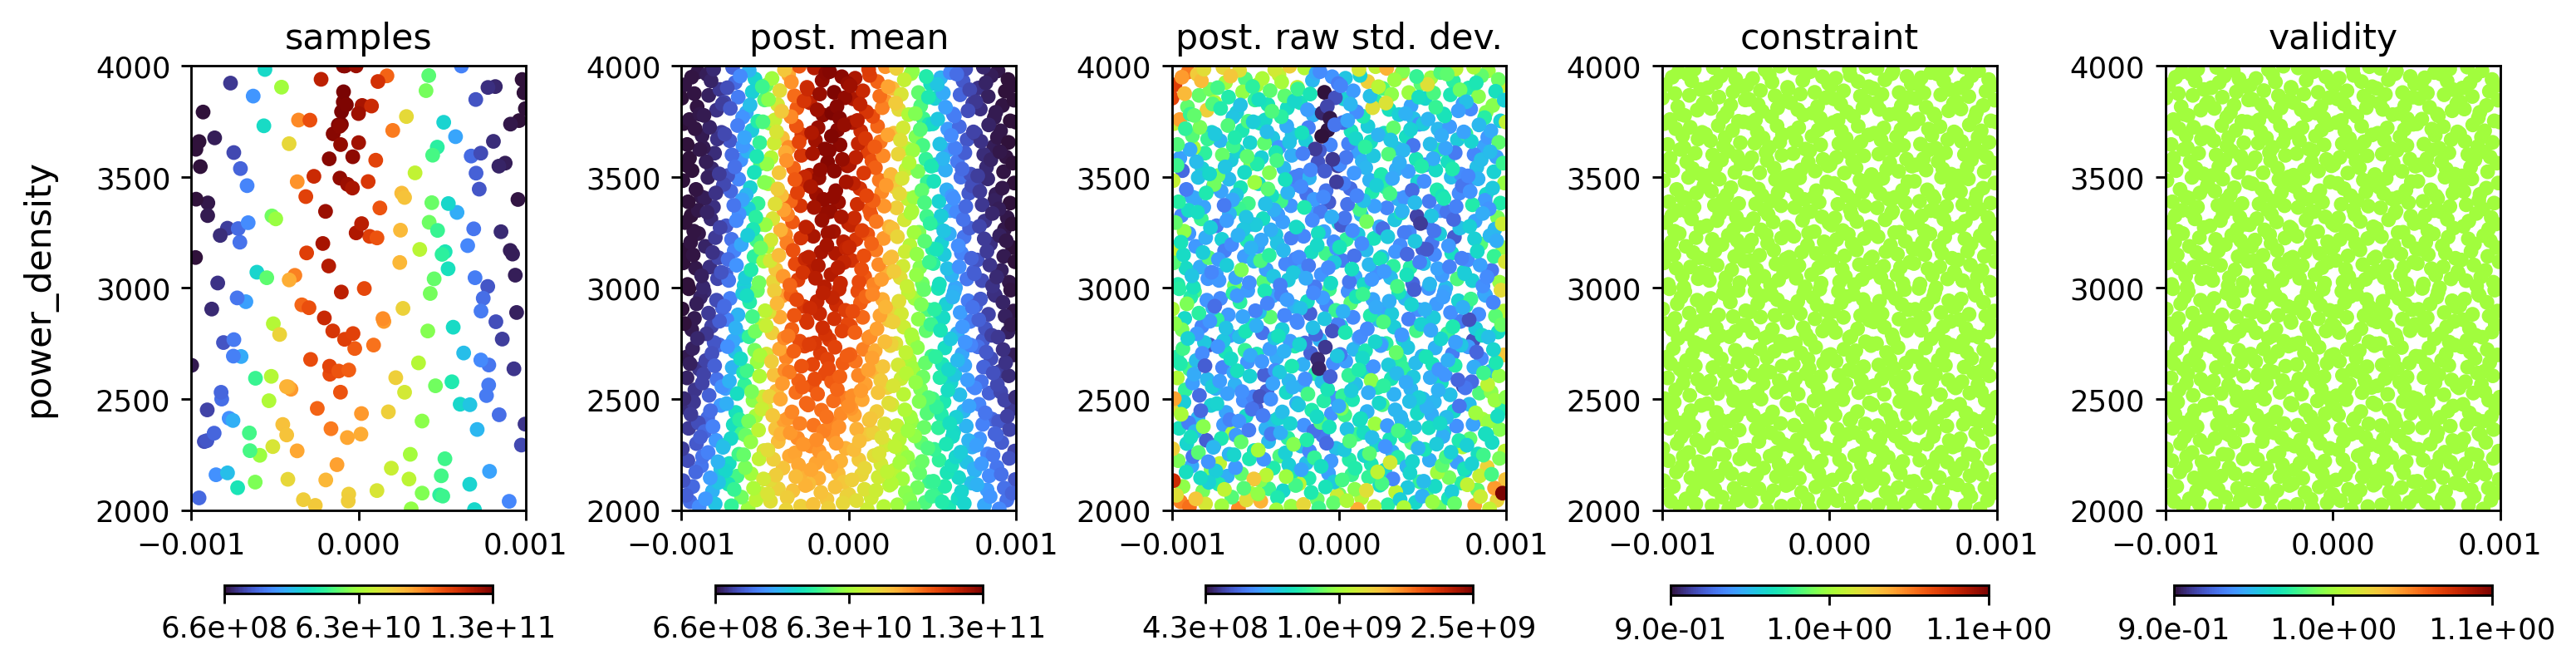

In [16]:
agent.plot_objectives()
print(agent.best)

19126
5898.943096146613
5898.943096146613 0.24301385751962012 0.07227905915883243 0.004381990324196633 -0.027663719997349904
14940
8480.07739231452
8480.07739231452 0.24726284705821241 0.08049036285220747 -0.0003148365127374746 -0.08969209760641028
14218
8735.731088361423
8735.731088361423 0.2449645071754667 0.09344913916850299 0.00036303162027459394 -0.06517767608457632


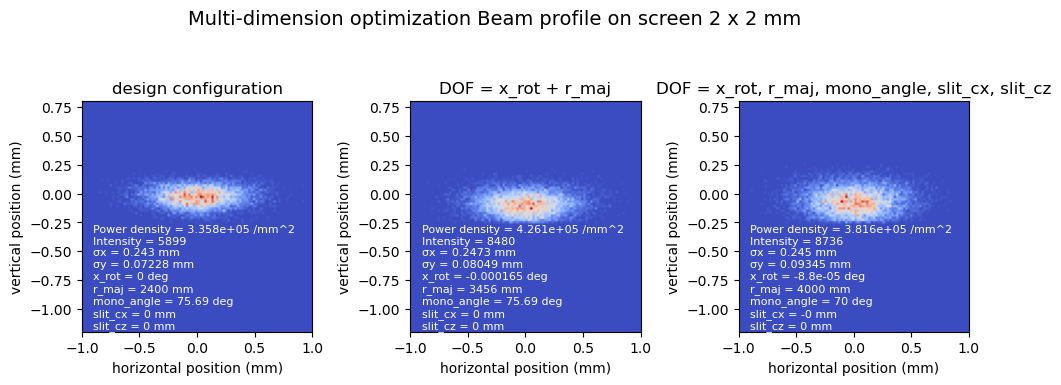

In [16]:
plt.figure(figsize=(10, 4))

# Overall figure title
plt.suptitle('Multi-dimension optimization Beam profile on screen 2 x 2 mm', fontsize=14)

# --- First subplot ---
x_rot =  0                                                                                                                                                                                                                                                                                                                                             
r_maj =  2400.0
mono_angle = 75.6898061088
slit_rx = 1e-3
slit_rz = 5e-4
slit_cx = 0.0
slit_cz = 0.0    
X, Y, I = beamline_531(x_rot, r_maj)#, SLIT_RX = entry.slit_rx, SLIT_RZ = entry.slit_rz)
        
X = X * 1e3
Y = Y * 1e3
intensity, sigma_x, sigma_y, x_centroid, y_centroid = beam_rms_size(X, Y, I)
print(intensity, sigma_x, sigma_y, x_centroid, y_centroid)
plt.subplot(1, 3, 1)
hist1, xedges, yedges = np.histogram2d(
    X, Y, bins=100, range=[[-1, 1], [-1.2, 0.8]], weights=I
)
plt.title('design configuration')
plt.imshow(hist1.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
          aspect='equal', origin='lower')
plt.xlabel('horizontal position (mm)')
plt.ylabel('vertical position (mm)')
plt.text(0.05, -0.05,
         f"Power density = {intensity/sigma_x/sigma_y:.4g} /mm^2\n"
         f"Intensity = {intensity:.4g}\n"
         f"σx = {sigma_x:.4g} mm\n"
         f"σy = {sigma_y:.4g} mm\n"
         f"x_rot = {x_rot:.4g} deg\n"
         f"r_maj = {r_maj:.4g} mm\n"
         f"mono_angle = {mono_angle:.4g} deg\n"
         f"slit_cx = {slit_cx * 1e3:.4g} mm\n"
         f"slit_cz = {slit_cz * 1e3:.4g} mm\n",
         transform=plt.gca().transAxes,
         fontsize=8, verticalalignment='bottom', color='white')

# --- second subplot ---
x_rot =  -0.000165
r_maj = 3456.432074    
mono_angle = 75.6898061088
slit_rx = 1e-3
slit_rz = 5e-4
slit_cx = 0.0
slit_cz = 0.0     
X, Y, I = beamline_531(x_rot, r_maj)#, mono_angle, slit_cx, slit_cz, slit_rx, slit_rz)#, SLIT_RX = entry.slit_rx, SLIT_RZ = entry.slit_rz)
        
X = X * 1e3
Y = Y * 1e3
intensity, sigma_x, sigma_y, x_centroid, y_centroid = beam_rms_size(X, Y, I)
print(intensity, sigma_x, sigma_y, x_centroid, y_centroid)
plt.subplot(1, 3, 2)
hist1, xedges, yedges = np.histogram2d(
    X, Y, bins=100, range=[[-1, 1], [-1.2, 0.8]], weights=I
)
plt.title('DOF = x_rot + r_maj')
plt.imshow(hist1.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
          aspect='equal', origin='lower')
plt.xlabel('horizontal position (mm)')
plt.ylabel('vertical position (mm)')
plt.text(0.05, -0.05,
         f"Power density = {intensity/sigma_x/sigma_y:.4g} /mm^2\n"
         f"Intensity = {intensity:.4g}\n"
         f"σx = {sigma_x:.4g} mm\n"
         f"σy = {sigma_y:.4g} mm\n"
         f"x_rot = {x_rot:.4g} deg\n"
         f"r_maj = {r_maj:.4g} mm\n"
         f"mono_angle = {mono_angle:.4g} deg\n"
         f"slit_cx = {slit_cx * 1e3:.4g} mm\n"
         f"slit_cz = {slit_cz * 1e3:.4g} mm\n",
         transform=plt.gca().transAxes,
         fontsize=8, verticalalignment='bottom', color='white')

# --- third subplot ---
x_rot =  -0.000088
r_maj = 4000
mono_angle = 70
slit_rx = 1e-3
slit_rz = 5e-4
slit_cx = -0.000
slit_cz = 0.0000   
X, Y, I = beamline_531(x_rot, r_maj, mono_angle, slit_cx, slit_cz, slit_rx, slit_rz)#, SLIT_RX = entry.slit_rx, SLIT_RZ = entry.slit_rz)
        
X = X * 1e3
Y = Y * 1e3
intensity, sigma_x, sigma_y, x_centroid, y_centroid = beam_rms_size(X, Y, I)
print(intensity, sigma_x, sigma_y, x_centroid, y_centroid)
plt.subplot(1, 3, 3)
hist1, xedges, yedges = np.histogram2d(
    X, Y, bins=100, range=[[-1, 1], [-1.2, 0.8]], weights=I
)
plt.title('DOF = x_rot, r_maj, mono_angle, slit_cx, slit_cz')
plt.imshow(hist1.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
          aspect='equal', origin='lower')
plt.xlabel('horizontal position (mm)')
plt.ylabel('vertical position (mm)')
plt.text(0.05, -0.05,
         f"Power density = {intensity/sigma_x/sigma_y:.4g} /mm^2\n"
         f"Intensity = {intensity:.4g}\n"
         f"σx = {sigma_x:.4g} mm\n"
         f"σy = {sigma_y:.4g} mm\n"
         f"x_rot = {x_rot:.4g} deg\n"
         f"r_maj = {r_maj:.4g} mm\n"
         f"mono_angle = {mono_angle:.4g} deg\n"
         f"slit_cx = {slit_cx * 1e3:.4g} mm\n"
         f"slit_cz = {slit_cz * 1e3:.4g} mm\n",
         transform=plt.gca().transAxes,
         fontsize=8, verticalalignment='bottom', color='white')

plt.tight_layout()

#### import numpy as np

# Define the scan ranges
x_rot_values =  np.linspace(-0.0004, 0, 4)  # 50 steps in x_rot
r_maj_values = np.linspace(2800, 3600, 30)     # 50 steps in r_maj

best_power_density = -np.inf
best_params = None

# Store results for analysis/plotting
results = []

for x_rot in x_rot_values:
    for r_maj in r_maj_values:
        # Run beamline simulation
        X, Y, I = beamline_531(x_rot, r_maj)

        # Convert to mm
        X = X * 1e3
        Y = Y * 1e3

        # Get beam stats
        intensity, sigma_x, sigma_y, x_centroid, y_centroid = beam_rms_size(X, Y, I)

        # Compute power density
        power_density = intensity / (sigma_x * sigma_y)

        results.append((x_rot, r_maj, power_density))

        # Track best
        if power_density > best_power_density:
            best_power_density = power_density
            best_params = (x_rot, r_maj)

# Report best result
print(f"Best power density: {best_power_density:.4f}")
print(f"Best parameters: x_rot = {best_params[0]:.6f}, r_maj = {best_params[1]:.6f}")

In [306]:
"""
# mirror pitch (DOF1)
oe1.X_ROT = 1e-09
# mirror bend (DOF2)
oe1.R_MAJ = 2400.0

# Mono angle – same variable  (DOF3)
oe2.T_INCIDENCE = 75.6898061088
oe2.T_REFLECTION = 75.6898061088
oe3.T_INCIDENCE = 75.6898061088
oe3.T_REFLECTION = 75.6898061088

# slit position (DOF4)
oe4.CX_SLIT = numpy.array([1e-09, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
oe4.CZ_SLIT = numpy.array([1e-09, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

# write (1) or not (0) SHADOW files start.xx end.xx star.xx

iwrite = 0
"""

def beamline_531(X_ROT = 0, R_MAJ = 2400, d_screen = 0):
    MONO_ANGLE = 75.6898061088
    SLIT_CX = 0
    SLIT_CZ = 0
    SLIT_RX = 1e-3
    SLIT_RZ = 5e-4
    # Define the object in beamline
    beam = Shadow.Beam()
    oe0 = Shadow.Source()
    oe1 = Shadow.OE()
    oe2 = Shadow.OE()
    oe3 = Shadow.OE()
    oe4 = Shadow.OE()
    oe5 = Shadow.OE()
    oe6 = Shadow.OE()
    
    
    oe0.FDISTR = 3
    oe0.F_PHOT = 0
    oe0.F_POLAR = 0
    oe0.HDIV1 = 0.0
    oe0.HDIV2 = 0.0
    oe0.IDO_VX = 0
    oe0.IDO_VZ = 0
    oe0.IDO_X_S = 0
    oe0.IDO_Y_S = 0
    oe0.IDO_Z_S = 0
    oe0.ISTAR1 = 0
    oe0.NPOINT = 50000
    oe0.PH1 = 8000.0
    oe0.SIGDIZ = 1e-05
    oe0.SIGMAX = 0.0003
    oe0.SIGMAZ = 0.0001
    oe0.VDIV1 = 0.0
    oe0.VDIV2 = 0.0
    
    
    
    oe1.ALPHA = 180.0
    oe1.DUMMY = 100.0
    oe1.FMIRR = 3
    oe1.FWRITE = 1
    oe1.F_EXT = 1
    oe1.F_MOVE = 1
    oe1.R_MAJ = R_MAJ
    oe1.R_MIN = 0.06
    oe1.T_IMAGE = 0.0
    oe1.T_INCIDENCE = 89.7135211024
    oe1.T_REFLECTION = 89.7135211024
    oe1.T_SOURCE = 12.0
    oe1.X_ROT = X_ROT
    oe1.Y_ROT = 0
    
    
    oe2.DUMMY = 100.0
    oe2.FILE_REFL = b'./bragg.dat'
    oe2.FWRITE = 1
    oe2.F_CENTRAL = 1
    oe2.F_CRYSTAL = 1
    oe2.PHOT_CENT = 8000.0
    oe2.R_LAMBDA = 5000.0
    oe2.T_IMAGE = 0.0
    oe2.T_INCIDENCE = MONO_ANGLE # 75.6898061088
    oe2.T_REFLECTION = MONO_ANGLE #75.6898061088
    
    
    
    oe3.ALPHA = 180.0
    oe3.DUMMY = 100.0
    oe3.FILE_REFL = b'./bragg.dat'
    oe3.FWRITE = 1
    oe3.F_CENTRAL = 1
    oe3.F_CRYSTAL = 1
    oe3.PHOT_CENT = 8000.0
    oe3.R_LAMBDA = 5000.0
    oe3.T_IMAGE = 0.0
    oe3.T_INCIDENCE = MONO_ANGLE # 75.6898061088
    oe3.T_REFLECTION = MONO_ANGLE # 75.6898061088
    oe3.T_SOURCE = 0.2

    
    oe4.CX_SLIT = np.array([SLIT_CX, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    oe4.CZ_SLIT = np.array([SLIT_CZ, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    oe4.DUMMY = 100.0
    oe4.FWRITE = 3
    oe4.F_REFRAC = 2
    oe4.F_SCREEN = 1
    oe4.I_SLIT = np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])
    oe4.N_SCREEN = 1
    oe4.RX_SLIT = np.array([SLIT_RX, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    oe4.RZ_SLIT = np.array([SLIT_RZ, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    oe4.T_IMAGE = 0.0
    oe4.T_INCIDENCE = 0.0
    oe4.T_REFLECTION = 180.0
    oe4.T_SOURCE = 0.8
    
    
    
    oe5.DUMMY = 100.0
    oe5.FWRITE = 3
    oe5.F_REFRAC = 2
    oe5.F_SCREEN = 1
    oe5.N_SCREEN = 1
    oe5.T_IMAGE = 0.0
    oe5.T_INCIDENCE = 0.0
    oe5.T_REFLECTION = 180.0
    oe5.T_SOURCE = 1.0 + d_screen

    beam.genSource(oe0)
    beam.traceOE(oe1,1)
    beam.traceOE(oe2,2)
    beam.traceOE(oe3,3)
    beam.traceOE(oe4,4)
    beam.traceOE(oe5,5)

    X = beam.getshcol(1)
    Y = beam.getshcol(3)
    # normalize the intensity by the number of rays
    valid = beam.getshcol(10) > 0
    intensity = (beam.getshcol(7)+beam.getshcol(16))**2 + (beam.getshcol(8)+beam.getshcol(17))**2 + (beam.getshcol(9)++beam.getshcol(18))**2
    mask = valid>0
    print(np.sum(mask))
    print(np.sum(intensity[mask]))
    X = X[mask]
    Y = Y[mask]
    intensity = intensity[mask]
    return X,Y,intensity

In [313]:
# testing the focal plane of the toroid mirror
results = []
d_screen = np.linspace(-1, 1, 100)     # 50 steps in r_maj
for d in d_screen:
    X, Y, intensity = beamline_531(d_screen = d)
    # Convert to mm
    X = X * 1e3
    Y = Y * 1e3

    # Get beam stats
    intensity, sigma_x, sigma_y, x_centroid, y_centroid = beam_rms_size(X, Y, intensity)

    # Compute power density
    power_density = intensity / (sigma_x * sigma_y)
    results.append(power_density)

18794
5858.132968085424
18663
5828.808874891948
18662
5785.275950556475
18801
5823.2544195964165
18862
5845.172160726374
18728
5813.371998195113
18588
5702.274820431846
18807
5837.9503257430515
18933
5877.5285103210545
19058
5850.358127477786
18689
5781.652838539522
18778
5834.975241311382
18806
5900.092826814204
18716
5855.137291496741
18744
5893.253488371411
18851
5839.474743469515
18639
5800.26068663374
18847
5855.679730405233
18827
5907.324705143327
18796
5781.905371038021
18853
5948.118819112403
18871
5918.814121818659
18691
5787.055126236459
18959
5916.973641443849
18640
5943.975543828207
18853
5858.370896938355
18679
5789.328742991113
18874
5927.264432311014
18605
5731.114010243357
18783
5865.801135959884
18742
5885.7417639302075
18944
5917.99908553639
18737
5886.916620038514
18509
5820.895762093029
18624
5780.84156497175
18900
5811.7002885467255
18746
5853.089199783624
18662
5836.501418237679
18932
5831.697916546669
18811
5918.612653764955
18928
5967.668605461645
18988
5859.691

Text(0, 0.5, 'power density (/mm^2)')

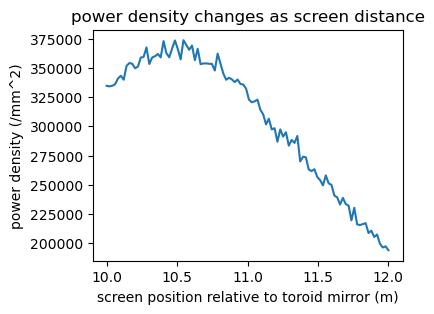

In [318]:
plt.figure(figsize = (4,3))
plt.plot(d_screen + 12 - 1, results)
plt.title('power density changes as screen distance')
plt.xlabel('screen position relative to toroid mirror (m)')
plt.ylabel('power density (/mm^2)')